# 📊 Phase 3: Exploratory Data Analysis (EDA)
Visualizing feature distributions, financial metrics, and relationships with Customer Churn.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv('data/cleaned_merged_data.csv')
except:
    df = pd.read_csv('cleaned_merged_data.csv')
print("✅ Cleaned data loaded for EDA.")

## 📊 Phase 3: Exploratory Data Analysis (EDA)
Generating professional visual dashboards to uncover patterns between spending, product selection, and churn risk.

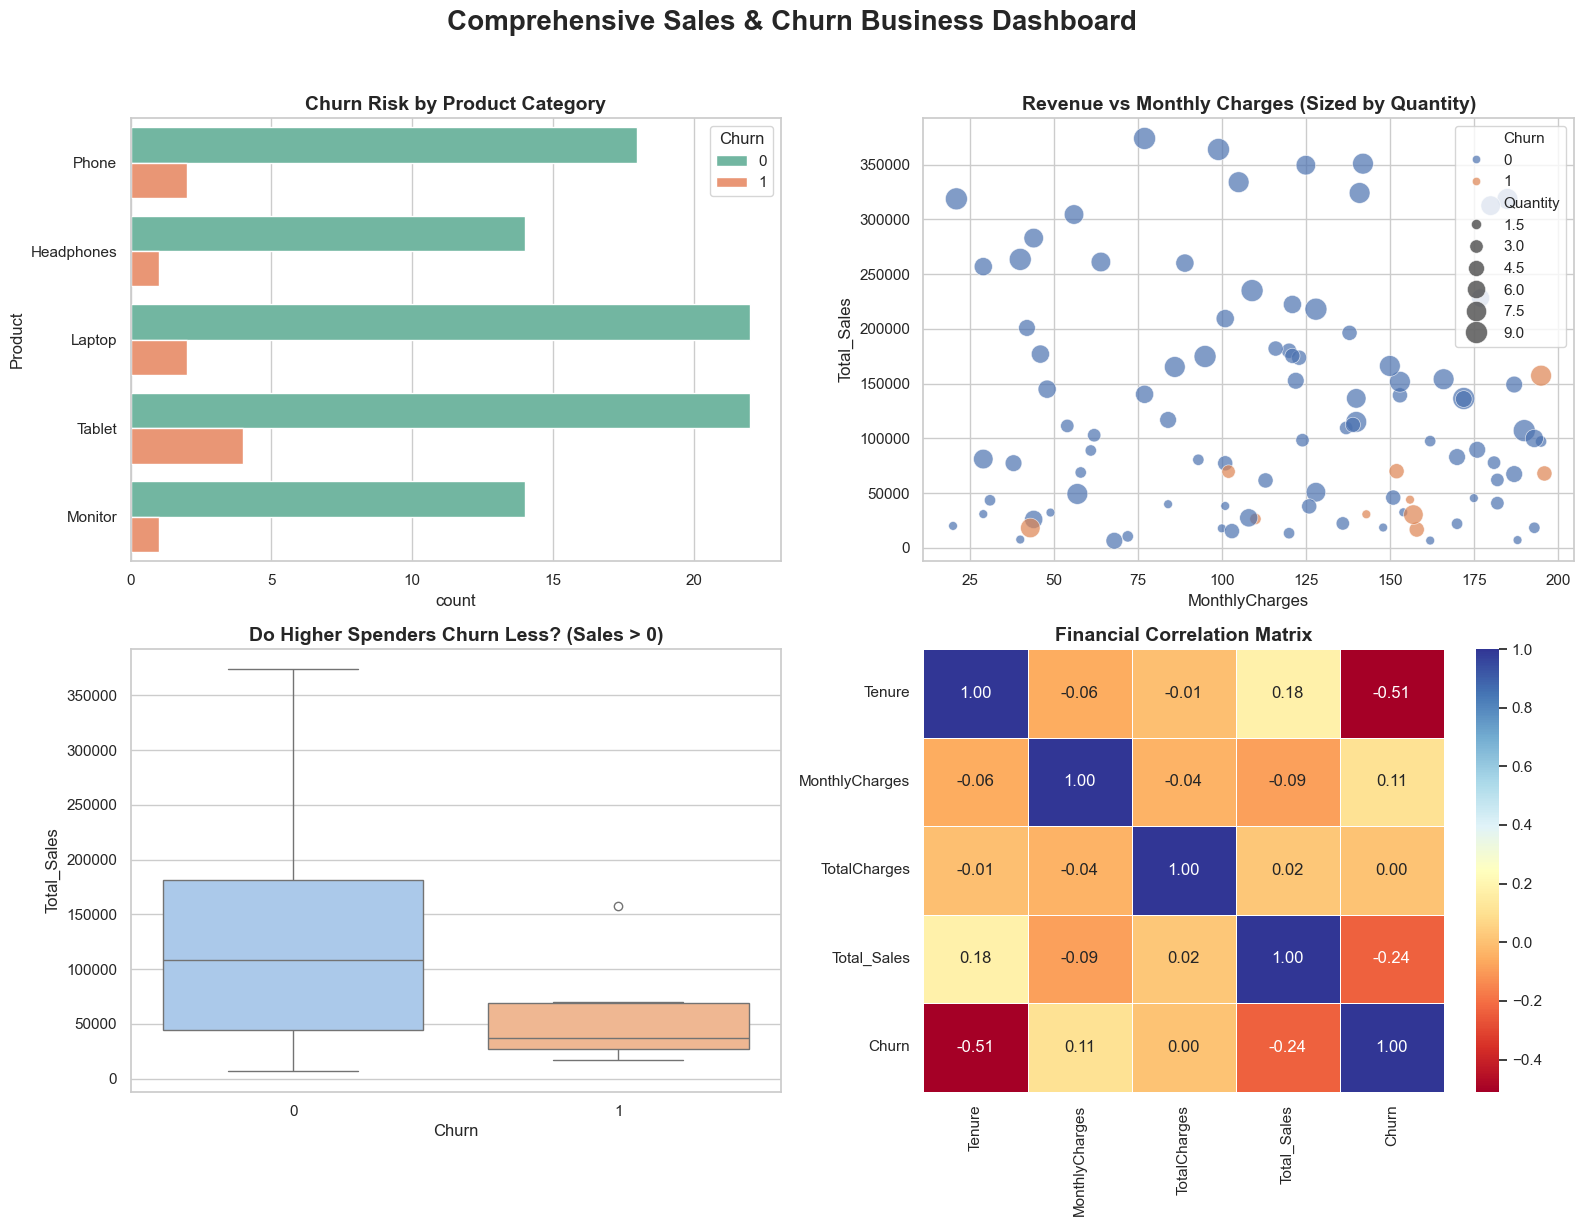

In [18]:
sns.set_theme(style='whitegrid', palette='deep')
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comprehensive Sales & Churn Business Dashboard', fontsize=20, fontweight='bold', y=1.02)

# 1. Churn Risk by Product Category
sns.countplot(y='Product', hue='Churn', data=df, ax=axs[0,0], palette='Set2')
axs[0,0].set_title('Churn Risk by Product Category', fontsize=14, fontweight='bold')

# 2. Revenue vs Monthly Subscription Charges
sns.scatterplot(x='MonthlyCharges', y='Total_Sales', hue='Churn', size='Quantity', sizes=(40, 250), alpha=0.7, data=df, ax=axs[0,1])
axs[0,1].set_title('Revenue vs Monthly Charges (Sized by Quantity)', fontsize=14, fontweight='bold')

# 3. Total Sales Distribution among Buyers
sns.boxplot(x='Churn', y='Total_Sales', data=df[df['Total_Sales'] > 0], ax=axs[1,0], palette='pastel')
axs[1,0].set_title('Do Higher Spenders Churn Less? (Sales > 0)', fontsize=14, fontweight='bold')

# 4. Financial Correlation Matrix
numeric_cols = df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Sales', 'Churn']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdYlBu', fmt=".2f", ax=axs[1,1], linewidths=0.5)
axs[1,1].set_title('Financial Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

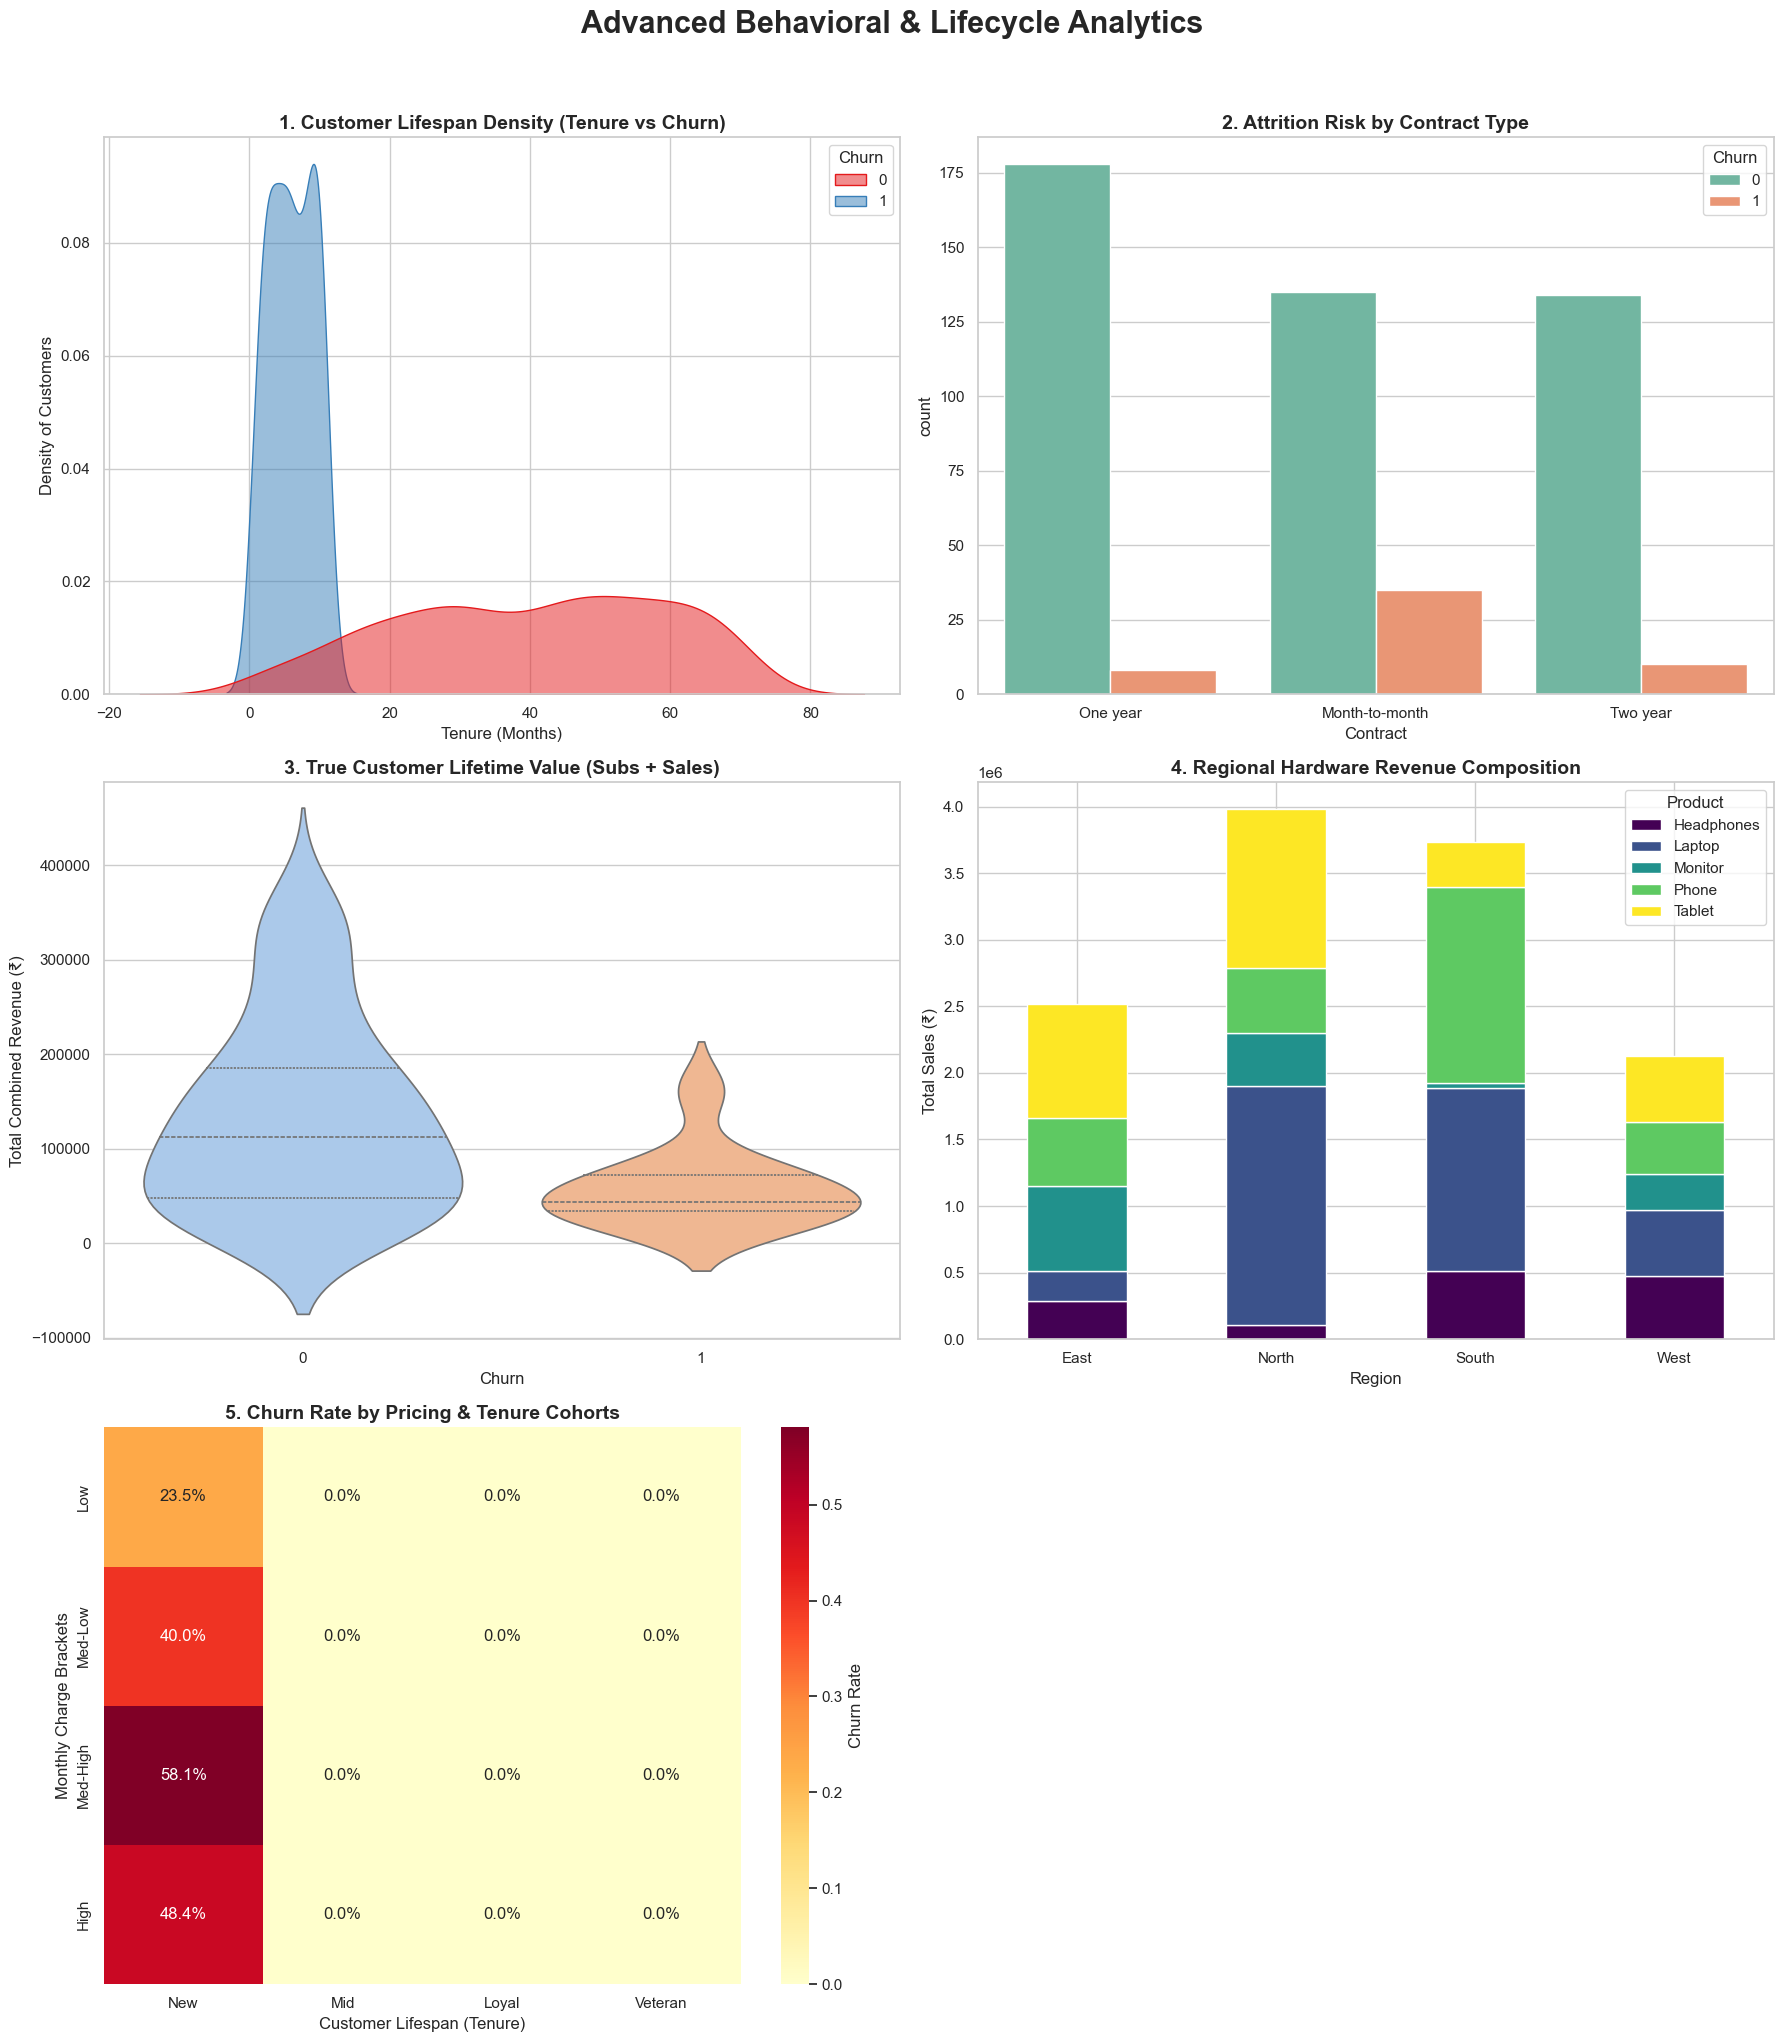

In [19]:
# CLTV = Subscription TotalCharges + Hardware Total_Sales
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['CLTV'] = df['TotalCharges'] + df['Total_Sales']

# Set up a 3x2 grid for 5 new advanced visualizations
fig, axs = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Advanced Behavioral & Lifecycle Analytics', fontsize=22, fontweight='bold', y=1.02)
sns.set_theme(style='whitegrid', palette='deep')

# ---------------------------------------------------
# VISUALIZATION 1: Tenure Density (The "Danger Zone")
# ---------------------------------------------------
sns.kdeplot(data=df, x='Tenure', hue='Churn', fill=True, common_norm=False, palette='Set1', ax=axs[0,0], alpha=0.5)
axs[0,0].set_title('1. Customer Lifespan Density (Tenure vs Churn)', fontsize=14, fontweight='bold')
axs[0,0].set_xlabel('Tenure (Months)')
axs[0,0].set_ylabel('Density of Customers')

# ----------------------------------------------
# VISUALIZATION 2: Contract Type Risk Assessment
# ----------------------------------------------
# Assuming 'Contract' exists in the churn dataset (standard for telecom/subscription datasets)
if 'Contract' in df.columns:
    sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', ax=axs[0,1])
    axs[0,1].set_title('2. Attrition Risk by Contract Type', fontsize=14, fontweight='bold')
else:
    axs[0,1].text(0.5, 0.5, 'Contract Column Missing', ha='center', va='center')

# ----------------------------------------------------
# VISUALIZATION 3: True Customer Lifetime Value (CLTV)
# ----------------------------------------------------
sns.violinplot(data=df, x='Churn', y='CLTV', palette='pastel', inner='quartile', ax=axs[1,0])
axs[1,0].set_title('3. True Customer Lifetime Value (Subs + Sales)', fontsize=14, fontweight='bold')
axs[1,0].set_ylabel('Total Combined Revenue (₹)')

# -------------------------------------------
# VISUALIZATION 4: Regional Hardware Adoption
# -------------------------------------------
# Filter out 'Unknown' or 'No Recent Purchase' to see real hardware sales footprint
real_sales = df[(df['Region'] != 'Unknown') & (df['Product'] != 'No Recent Purchase')]
if not real_sales.empty:
    sales_pivot = real_sales.groupby(['Region', 'Product'])['Total_Sales'].sum().unstack().fillna(0)
    sales_pivot.plot(kind='bar', stacked=True, ax=axs[1,1], colormap='viridis')
    axs[1,1].set_title('4. Regional Hardware Revenue Composition', fontsize=14, fontweight='bold')
    axs[1,1].set_ylabel('Total Sales (₹)')
    axs[1,1].tick_params(axis='x', rotation=0)
else:
    axs[1,1].text(0.5, 0.5, 'Insufficient Regional Data', ha='center', va='center')

# ---------------------------------------
# VISUALIZATION 5: Pricing Cohort Heatmap
# ---------------------------------------
# Create bins for Monthly Charges and Tenure to see exactly WHERE people churn
df['Tenure_Bin'] = pd.qcut(df['Tenure'], q=4, labels=['New', 'Mid', 'Loyal', 'Veteran'])
df['Charge_Bin'] = pd.qcut(df['MonthlyCharges'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])

cohort_churn = df.groupby(['Charge_Bin', 'Tenure_Bin'])['Churn'].mean().unstack()
sns.heatmap(cohort_churn, annot=True, fmt=".1%", cmap='YlOrRd', ax=axs[2,0], cbar_kws={'label': 'Churn Rate'})
axs[2,0].set_title('5. Churn Rate by Pricing & Tenure Cohorts', fontsize=14, fontweight='bold')
axs[2,0].set_xlabel('Customer Lifespan (Tenure)')
axs[2,0].set_ylabel('Monthly Charge Brackets')

# Remove the empty 6th subplot
axs[2,1].axis('off')

plt.tight_layout()
plt.show()